In [1]:
from google.colab import files
import pickle

# Upload QR codes
uploaded_qr = files.upload()
qr_filename = list(uploaded_qr.keys())[0]

# Upload labels
uploaded_labels = files.upload()
labels_filename = list(uploaded_labels.keys())[0]

# Load QR codes
with open(qr_filename, 'rb') as f:
    qr_codes = pickle.load(f)

# Load labels
with open(labels_filename, 'rb') as f:
    qr_labels = pickle.load(f)

# Check
print("QR codes:")
print(type(qr_codes), qr_codes.shape)

print("\nLabels:")
print(type(qr_labels), qr_labels.shape)

Saving qr_codes_29.pickle to qr_codes_29.pickle


Saving qr_codes_29_labels.pickle to qr_codes_29_labels.pickle
QR codes:
<class 'numpy.ndarray'> (9987, 69, 69)

Labels:
<class 'numpy.ndarray'> (9987,)


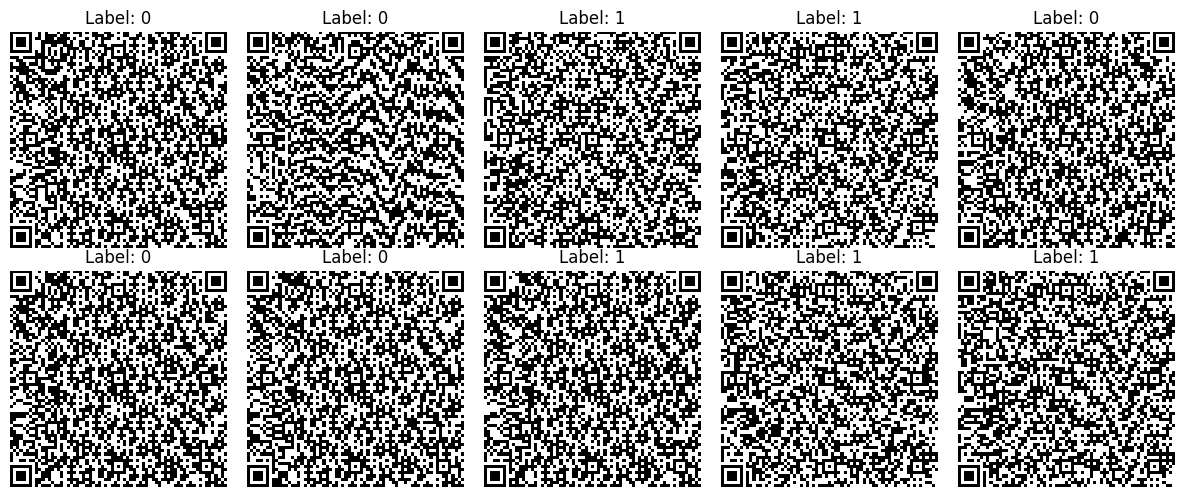

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Select 10 random samples
indices = np.random.choice(len(qr_codes), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(qr_codes[indices[i]], cmap="gray")
    ax.set_title(f"Label: {qr_labels[indices[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("QR codes shape:", qr_codes.shape)
print("Labels shape:", qr_labels.shape)

print("QR codes dtype:", qr_codes.dtype)
print("Labels dtype:", qr_labels.dtype)

print("Unique labels:", np.unique(qr_labels, return_counts=True))

QR codes shape: (9987, 69, 69)
Labels shape: (9987,)
QR codes dtype: int16
Labels dtype: int32
Unique labels: (array([0, 1], dtype=int32), array([5005, 4982]))


In [4]:
X = np.asarray(qr_codes)
y = np.asarray(qr_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9987, 69, 69)
y shape: (9987,)


In [5]:
if X.ndim == 3:
    X = np.expand_dims(X, axis=-1)

print("New X shape:", X.shape)

New X shape: (9987, 69, 69, 1)


In [6]:
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0
Maximum pixel value: 1


In [7]:
X = X.astype("float32")

if X.max() > 1:
    X = X / 255.0

print("New pixel range:", X.min(), X.max())

New pixel range: 0.0 1.0


In [8]:
y = y.astype("int32")

print("Unique labels:", np.unique(y))
print("Number of samples:", len(y))

Unique labels: [0 1]
Number of samples: 9987


In [9]:
assert set(np.unique(y)).issubset({0, 1}), "Labels must be binary (0 and 1)"

In [10]:
unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count} samples ({count / len(y) * 100:.2f}%)")

Class 0: 5005 samples (50.12%)
Class 1: 4982 samples (49.88%)


In [11]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (6990, 69, 69, 1) (6990,)
Validation: (1498, 69, 69, 1) (1498,)
Testing: (1499, 69, 69, 1) (1499,)


In [12]:
print("Training distribution:")
print(np.unique(y_train, return_counts=True))

print("\nValidation distribution:")
print(np.unique(y_val, return_counts=True))

print("\nTesting distribution:")
print(np.unique(y_test, return_counts=True))

Training distribution:
(array([0, 1], dtype=int32), array([3503, 3487]))

Validation distribution:
(array([0, 1], dtype=int32), array([751, 747]))

Testing distribution:
(array([0, 1], dtype=int32), array([751, 748]))


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    layers.Input(shape=X_train.shape[1:]),

    # Block 1
    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(32, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.20),

    # Block 2
    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(64, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(128, (3,3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.30),

    # Classification
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 69, 69, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 17, 17, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 17, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 17, 17, 128)    │             

 Total params: 305,377 (1.16 MB)

 Trainable params: 304,225 (1.16 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [14]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

checkpoint = ModelCheckpoint(
    "best_qr_cnn.keras",
    monitor="val_loss",
    save_best_only=True
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 66ms/step - accuracy: 0.6781 - loss: 0.6213 - precision: 0.7049 - recall: 0.6103 - val_accuracy: 0.5013 - val_loss: 1.9322 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7296 - loss: 0.5306 - precision: 0.7905 - recall: 0.6232 - val_accuracy: 0.5013 - val_loss: 1.8274 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.7455 - loss: 0.5040 - precision: 0.8009 - recall: 0.6518 - val_accuracy: 0.7163 - val_loss: 0.5522 - val_precision: 0.9107 - val_recall: 0.4779 - learning_rate: 0.0010
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7724 - loss: 0.4718 - precision: 0.8175 - recall: 0.7000 - val_accuracy: 0.5901 - val_loss: 0.9987 - val_precision: 0.9784 - val_recall: 0.1821 - learning_rate: 0.0010
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 

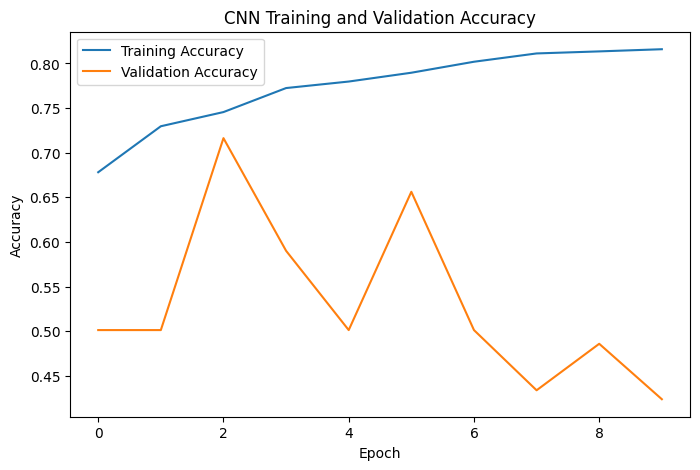

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()

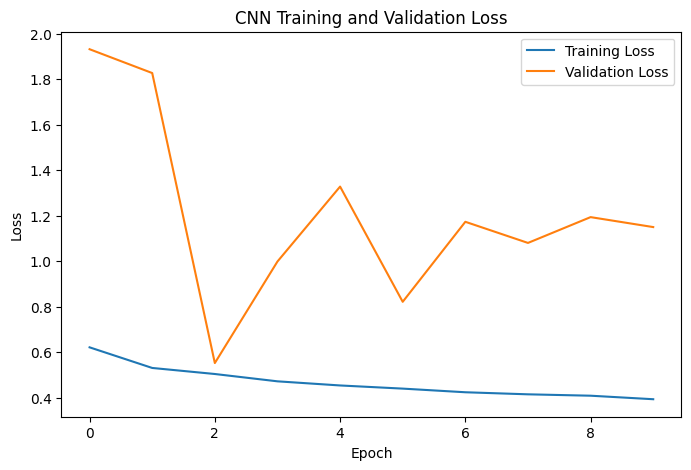

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()

In [19]:
test_results = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\nTest Results:")

for name, value in zip(model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7472 - loss: 0.5247 - precision: 0.9203 - recall: 0.5401

Test Results:
loss: 0.5247
compile_metrics: 0.7472


In [20]:
y_prob = model.predict(X_test)

47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step


In [21]:
y_pred = (y_prob >= 0.5).astype(int).ravel()

In [22]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Phishing"],
        digits=4
    )
)

              precision    recall  f1-score   support

      Benign     0.6755    0.9534    0.7907       751
    Phishing     0.9203    0.5401    0.6807       748

    accuracy                         0.7472      1499
   macro avg     0.7979    0.7468    0.7357      1499
weighted avg     0.7976    0.7472    0.7358      1499



In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[716  35]
 [344 404]]


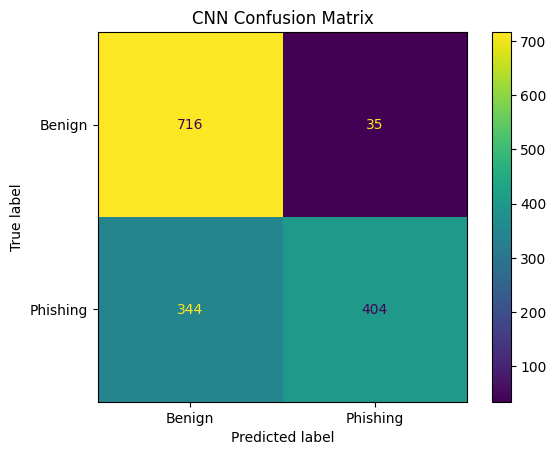

In [24]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Phishing"]
)

disp.plot()

plt.title("CNN Confusion Matrix")
plt.show()

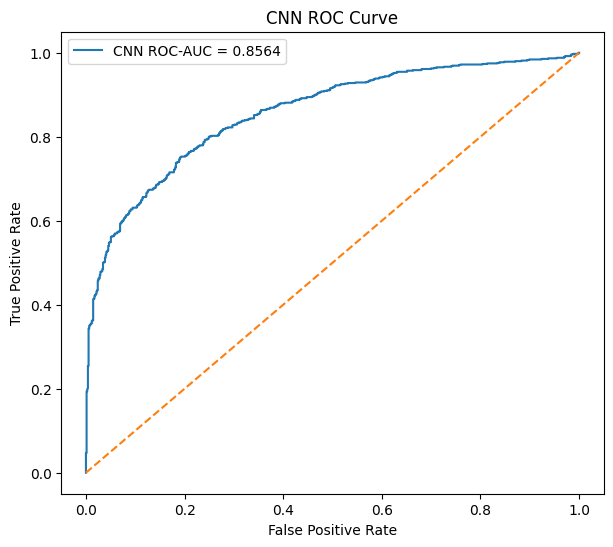

In [25]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob.ravel()
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"CNN ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN ROC Curve")
plt.legend()

plt.show()

In [26]:
# Convert grayscale (69,69,1) -> RGB-like (69,69,3) by repeating the channel
X_train_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_train)).numpy()
X_val_rgb = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_val)).numpy()

print(X_train_rgb.shape)

(6990, 69, 69, 3)


In [27]:
IMG_SIZE = (96, 96)

X_train_rgb = tf.image.resize(X_train_rgb, IMG_SIZE).numpy()
X_val_rgb = tf.image.resize(X_val_rgb, IMG_SIZE).numpy()

INPUT_SHAPE = X_train_rgb.shape[1:]
print(INPUT_SHAPE)

(96, 96, 3)


In [28]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

IMG_SIZE = X_train_rgb.shape[1:3]  # e.g. (224, 224) — resize your data to this if needed
INPUT_SHAPE = X_train_rgb.shape[1:]

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=INPUT_SHAPE,
)
base_model.trainable = False  # freeze for stage 1

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

inputs = layers.Input(shape=INPUT_SHAPE)
x = data_augmentation(inputs)
x = keras.applications.efficientnet_v2.preprocess_input(x)  # backbone-specific preprocessing
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 3, 3, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,083,921 (23.21 MB)

 Trainable params: 164,353 (642.00 KB)

 Non-trainable params: 5,919,568 (22.58 MB)

In [30]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1),
]


In [31]:
history = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)

base_model.trainable = True

# Freeze all but the last ~30 layers — reasonable default for small/medium datasets
for layer in base_model.layers[:-30]:
    layer.trainable = False

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 28s 50ms/step - accuracy: 0.5016 - auc: 0.4995 - loss: 0.8413 - val_accuracy: 0.5013 - val_auc: 0.4875 - val_loss: 0.7227 - learning_rate: 0.0010
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.4989 - auc: 0.5051 - loss: 0.7383 - val_accuracy: 0.5013 - val_auc: 0.4269 - val_loss: 0.7082 - learning_rate: 0.0010
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.5011 - auc: 0.5039 - loss: 0.7094 - val_accuracy: 0.4987 - val_auc: 0.3742 - val_loss: 0.9172 - learning_rate: 0.0010
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4956 - auc: 0.4968 - loss: 0.7011 - val_accuracy: 0.5013 - val_auc: 0.4262 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5072 - auc: 0.5126 - loss: 0.6955 - val_accuracy: 0.5013 - val_auc: 0.4369 - val_loss: 0.7597 - learning_rate: 0.0010
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.4874 - 

In [32]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # much lower LR — critical
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

In [33]:
callbacks_finetune = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss", verbose=1),
]

In [34]:
history_fine = model.fit(
    X_train_rgb, y_train,
    validation_data=(X_val_rgb, y_val),
    epochs=20,
    batch_size=32,
    callbacks=callbacks_finetune
)

val_loss, val_acc, val_auc = model.evaluate(X_val_rgb, y_val)
print(f"Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 29s 55ms/step - accuracy: 0.4983 - auc: 0.4999 - loss: 0.7567 - val_accuracy: 0.4987 - val_auc: 0.5242 - val_loss: 0.6934 - learning_rate: 1.0000e-05
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.5087 - auc: 0.5076 - loss: 0.7466 - val_accuracy: 0.4920 - val_auc: 0.5234 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.5066 - auc: 0.5038 - loss: 0.7473 - val_accuracy: 0.4973 - val_auc: 0.5351 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - accuracy: 0.5080 - auc: 0.5064 - loss: 0.7419 - val_accuracy: 0.4853 - val_auc: 0.5594 - val_loss: 0.6930 - learning_rate: 1.0000e-05
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 17s 77ms/step - accuracy: 0.4928 - auc: 0.4952 - loss: 0.7474 - val_accuracy: 0.5007 - val_auc: 0.5268 - val_loss: 0.6931 - learning_rate: 1.0000e-05
Epoch 6/20
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

In [35]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_proba = model.predict(X_val_rgb).ravel()
y_pred = (y_pred_proba > 0.5).astype(int)

print(classification_report(y_val, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba))

47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step
              precision    recall  f1-score   support

           0       0.25      0.02      0.04       751
           1       0.49      0.93      0.64       747

    accuracy                           0.48      1498
   macro avg       0.37      0.48      0.34      1498
weighted avg       0.37      0.48      0.34      1498

Confusion matrix:
 [[ 18 733]
 [ 53 694]]
ROC-AUC: 0.5292158425089617
